In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta

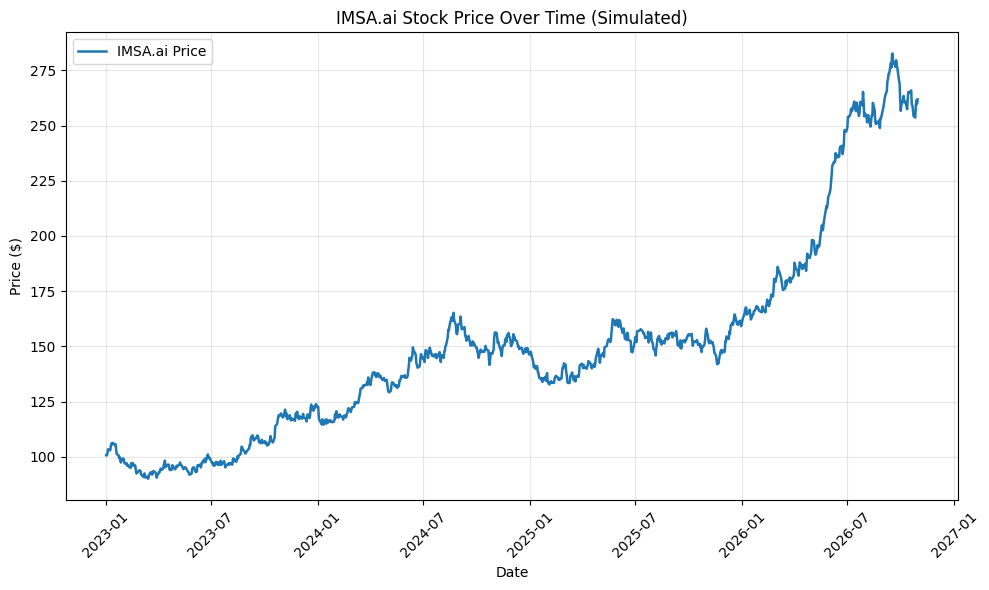

In [9]:
# Generate 1,000 business days of dates
start_date = datetime(2023, 1, 1)
dates = pd.date_range(start=start_date, periods=1000, freq='B')

# Simulate a generally increasing (bullish) stock path with daily noise
np.random.seed(42)
num_days = len(dates)
start_price = 100.0

# Positive drift + random noise for realistic day-to-day movement
daily_returns = np.random.normal(loc=0.0008, scale=0.012, size=num_days)
prices = start_price * np.cumprod(1 + daily_returns)

# Create DataFrame with only Date and Close-equivalent Price
data = pd.DataFrame({
    'Date': dates,
    'Price': prices
})

# Plot the simulated close price over time
plt.figure(figsize=(10, 6))
plt.plot(data['Date'], data['Price'], label='IMSA.ai Price', color='tab:blue', linewidth=1.8)
plt.title('IMSA.ai Stock Price Over Time (Simulated)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
data.shape

(1000, 2)

In [12]:
# imports for an pytorch RNN
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

In [13]:
# data preprocessing for RNN is interesting. first, you want to make a shifting window of sequences. here i'm going to use the past 14 days of stock data to predict the next, so my window size is going to be 15
window_size = 15
series = data['Price'].reset_index(drop=True)

#table with the past t-14, t-13, t-12, ..., t-1, and t (today)
sequence_table = pd.concat([series.shift(i) for i in range(window_size - 1, -1, -1)], axis=1)
sequence_table.columns = [f"t-{i}" for i in range(window_size - 1, 0, -1)] + ['t']
sequence_table = sequence_table.dropna().reset_index(drop=True)
sequence_table.head()

,t-14,t-13,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1,t
0,100.676057,100.589559,101.451839,103.387171,103.179379,102.972025,105.005780,106.056805,105.544159,106.315763,105.809593,105.302896,105.692890,103.350803,101.294224
1,100.589559,101.451839,103.387171,103.179379,102.972025,105.005780,106.056805,105.544159,106.315763,105.809593,105.302896,105.692890,103.350803,101.294224,100.691782
2,101.451839,103.387171,103.179379,102.972025,105.005780,106.056805,105.544159,106.315763,105.809593,105.302896,105.692890,103.350803,101.294224,100.691782,99.548530
3,103.387171,103.179379,102.972025,105.005780,106.056805,105.544159,106.315763,105.809593,105.302896,105.692890,103.350803,101.294224,100.691782,99.548530,100.003563
4,103.179379,102.972025,105.005780,106.056805,105.544159,106.315763,105.809593,105.302896,105.692890,103.350803,101.294224,100.691782,99.548530,100.003563,98.993898


In [16]:
# then you want to split it up into training, validation, and testing (0.7, 0.15, 0.15)
# because our data has been split up, we can ignore the fact that it is time-series and use traintestsplit

from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    sequence_table,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,  # 15% of total each
    random_state=42,
    shuffle=True
)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

len(train_data), len(val_data), len(test_data)

(690, 148, 148)

In [17]:
train_data.head()

,t-14,t-13,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1,t
0,147.117773,149.420725,146.681375,145.743714,145.869480,146.068412,145.396383,146.599421,144.838550,144.706957,145.031614,146.042958,147.406908,145.535473,142.972685
1,147.512208,146.279138,143.227962,140.545229,140.738763,141.289990,139.869771,141.053505,138.353989,138.354963,136.455046,135.496854,135.682320,134.389951,133.877298
2,166.385818,166.145813,165.402016,168.406335,168.938273,171.165240,168.250856,168.924634,170.863141,171.168543,173.493998,172.555836,175.612174,180.597238,179.955384
3,155.522740,153.037049,154.193341,153.112798,152.340267,151.379194,149.930815,150.138058,148.761082,149.362892,149.392338,149.083487,147.579121,146.675752,148.122663
4,159.693596,155.913523,155.534204,156.997860,159.953860,160.224044,163.483544,160.906844,157.746539,157.767587,158.620918,158.685581,154.875651,154.833921,152.534075


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [23]:
feature_cols = [c for c in sequence_table.columns if c != 't']
target_col = 't'

X_train_np = train_data[feature_cols].values
X_val_np = val_data[feature_cols].values
X_test_np = test_data[feature_cols].values

y_train_np = train_data[[target_col]].values
y_val_np = val_data[[target_col]].values
y_test_np = test_data[[target_col]].values

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = x_scaler.fit_transform(X_train_np)
X_val_scaled = x_scaler.transform(X_val_np)
X_test_scaled = x_scaler.transform(X_test_np)

y_train_scaled = y_scaler.fit_transform(y_train_np)
y_val_scaled = y_scaler.transform(y_val_np)
y_test_scaled = y_scaler.transform(y_test_np)

seq_len = X_train_scaled.shape[1]
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).reshape(-1, seq_len, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).reshape(-1, seq_len, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).reshape(-1, seq_len, 1)

y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

X_train_t.shape, y_train_t.shape

(torch.Size([690, 14, 1]), torch.Size([690, 1]))

In [24]:
class PriceRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PriceRNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device

device(type='cpu')

In [25]:
epochs = 40
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_train = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * xb.size(0)

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            running_val += loss.item() * xb.size(0)

    epoch_train_loss = running_train / len(train_loader.dataset)
    epoch_val_loss = running_val / len(val_loader.dataset)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

train_losses[-1], val_losses[-1]

(0.0003155897537658018, 0.00039314755200836306)

In [26]:
model.eval()
with torch.no_grad():
    y_test_pred_scaled = model(X_test_t.to(device)).cpu().numpy()

y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled).ravel()
y_test_true = y_scaler.inverse_transform(y_test_t.numpy()).ravel()

rmse = mean_squared_error(y_test_true, y_test_pred) ** 0.5
mae = mean_absolute_error(y_test_true, y_test_pred)
rmse, mae

(4.20638015795091, 3.1623971462249756)

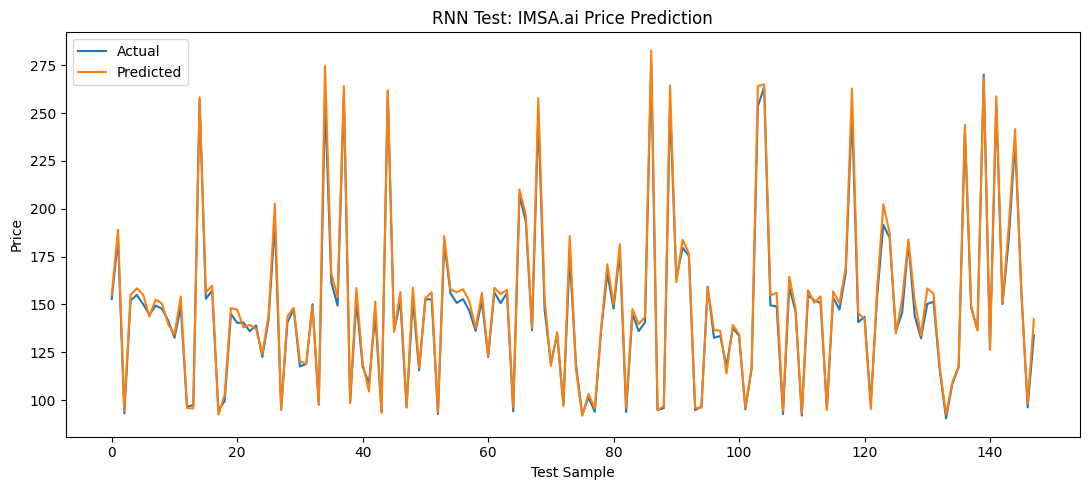

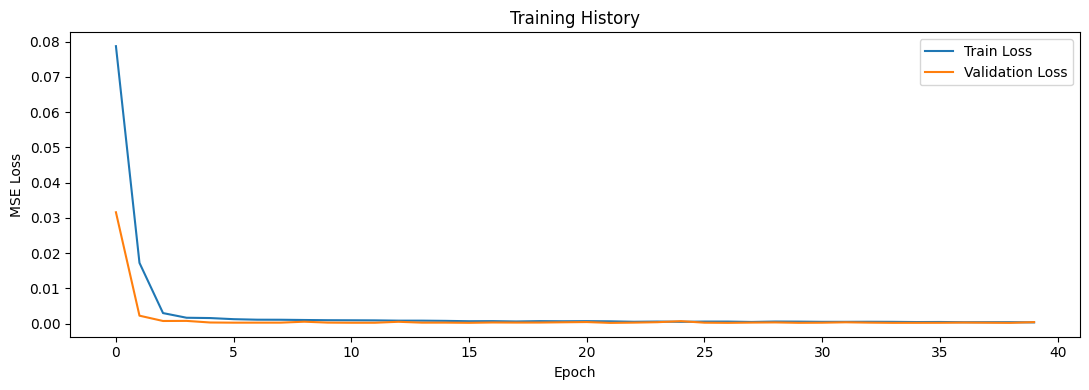

In [27]:
plt.figure(figsize=(11, 5))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title('RNN Test: IMSA.ai Price Prediction')
plt.xlabel('Test Sample')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

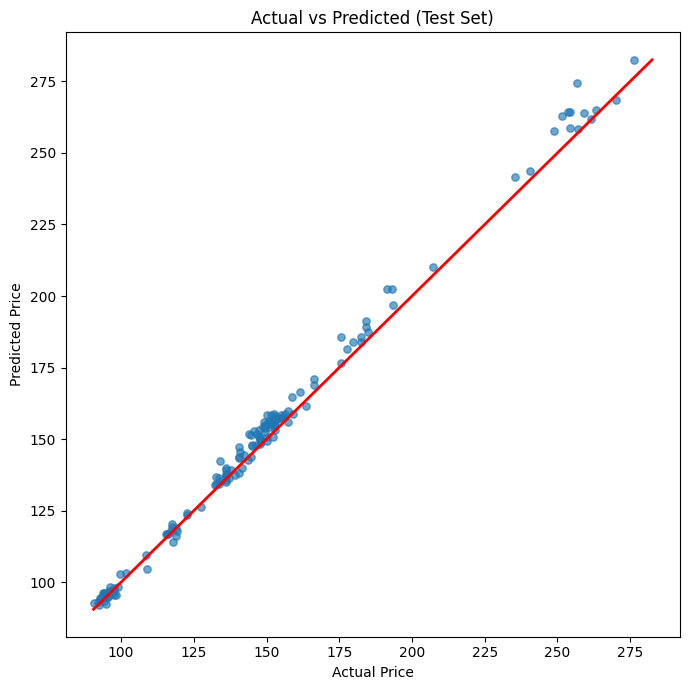

In [28]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_true, y_test_pred, alpha=0.65, s=28)
min_v = min(y_test_true.min(), y_test_pred.min())
max_v = max(y_test_true.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], color='red', linewidth=2)
plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()